In [1]:
from world import World

WIDTH, HEIGHT = 100, 100

world = World(WIDTH, HEIGHT)

In [2]:
world.add_prey(number=20)
world.add_predator(number=10)

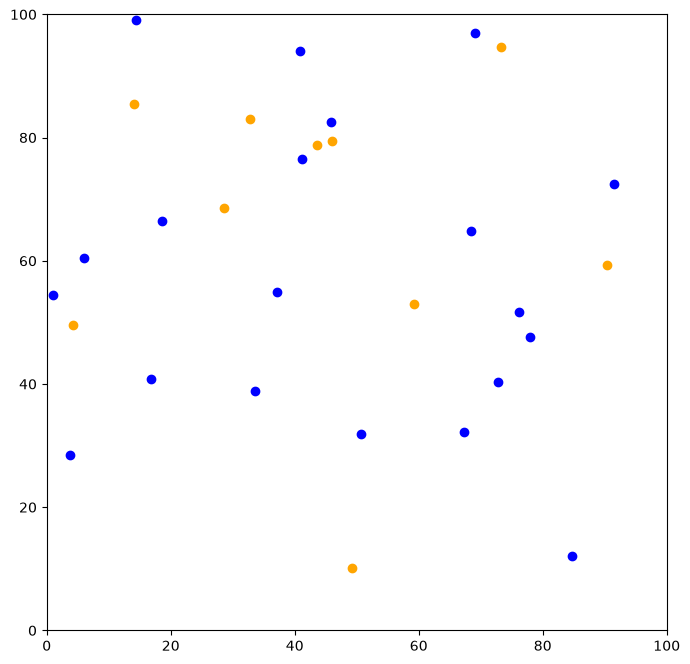

In [3]:
import matplotlib.pyplot as plt

# plot the world with the preys and predators
plt.figure(figsize=(8, 8))
plt.xlim(0, world.width)
plt.ylim(0, world.height)

for prey in world.preys:
    plt.scatter(prey.x, prey.y, c=world.color_prey)
for predator in world.predators:
    plt.scatter(predator.x, predator.y, c=world.color_predator)
plt.show()

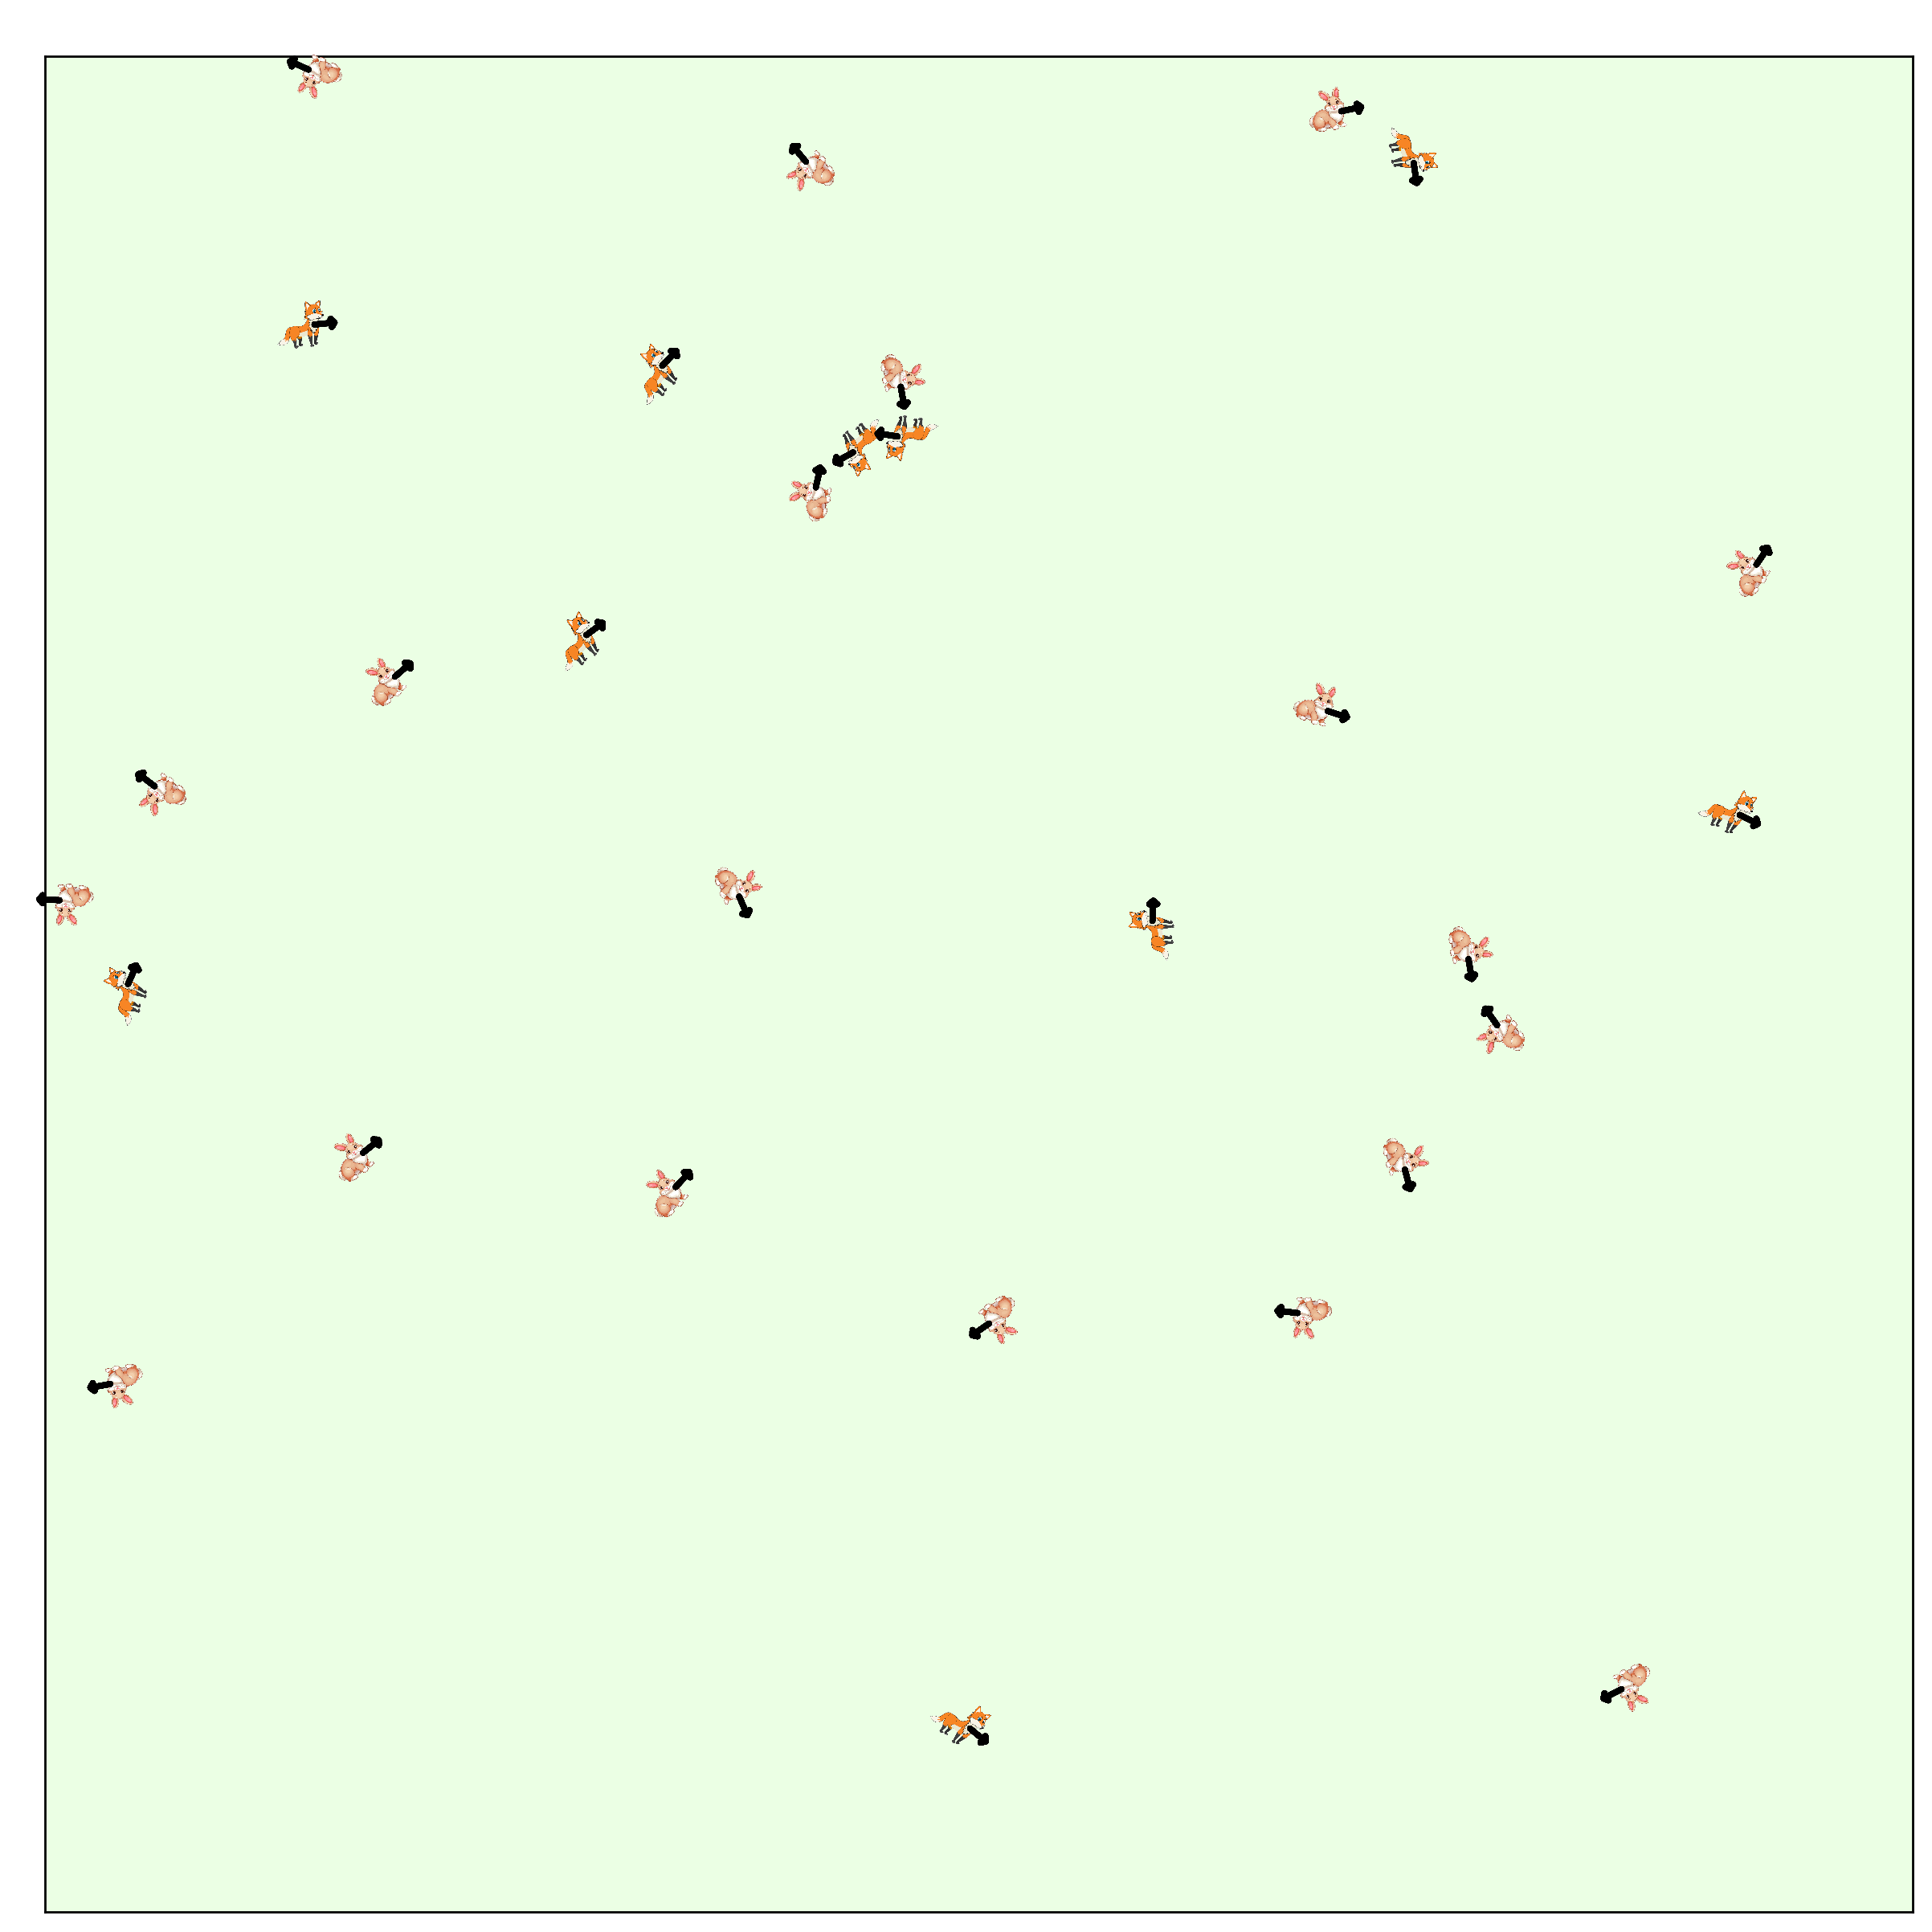

In [4]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import numpy as np


# Loading the images with PIL
hare_img = Image.open("./images/hare.png")
fox_img = Image.open("./images/fox.png")


plt.figure(figsize=(12, 12), dpi=250)
plt.xlim(0, world.width)
plt.ylim(0, world.height)

# initialization of the axes
ax = plt.gca()

# color of the background
ax.set_facecolor("#ebffe4")

# Hide the axes
ax.set_xticks([])
ax.set_yticks([])

for prey in world.preys:
    # Conversion in degree
    direction = prey.direction*180/np.pi  
    # Rotation of the image
    rotated_img = hare_img.rotate(
        -direction,
        resample=Image.Resampling.BICUBIC,
        expand=True
    )

    hare_icon = OffsetImage(
        np.array(rotated_img),
        zoom=0.05
    )

    ab = AnnotationBbox(
        hare_icon,
        (prey.x, prey.y),
        frameon=False
    )

    ax.add_artist(ab)


for predator in world.predators:

    direction = predator.direction*180/np.pi

    rotated_img = fox_img.rotate(
        -direction,
        resample=Image.Resampling.BICUBIC,
        expand=True
    )

    fox_icon = OffsetImage(
        np.array(rotated_img),
        zoom=0.05
    )

    ab = AnnotationBbox(
        fox_icon,
        (predator.x, predator.y),
        frameon=False
    )

    ax.add_artist(ab)


plt.show()

In [5]:
from tqdm import tqdm

def run_simulation(world, N):
    """Run the simulation and store the state at each time step."""
    history = {}
    pbar = tqdm(range(N), desc="Simulation")

    for t in pbar:
        dict_agent = world.return_dict()
        history[t] = dict_agent
        
        world.step()

    return history

world.remove_all_agents()
world.add_prey(number=40)
world.add_predator(number=20)

N = 200

history = run_simulation(world, N)

Simulation: 100%|██████████| 200/200 [01:24<00:00,  2.36it/s]


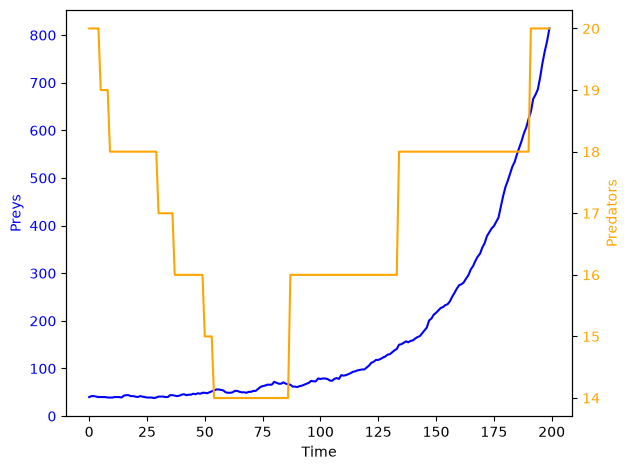

In [6]:
# plot the number of preys and predators over time
prey_counts = [len(history[t]['preys']) for t in range(N)]
predator_counts = [len(history[t]['predators']) for t in range(N)]

import matplotlib.pyplot as plt
fig, ax1 = plt.subplots()

color = world.color_prey
ax1.set_xlabel('Time')
ax1.set_ylabel('Preys', color=color)
ax1.plot(range(N), prey_counts, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = world.color_predator
ax2.set_ylabel('Predators', color=color)
ax2.plot(range(N), predator_counts, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped


plt.show()

In [7]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"

import pygame
import numpy as np
import imageio


def render_simulation(
    history,
    world_width,
    world_height,
    output_path="./plot/world.gif",
    scale=8,
    output_size=(800, 800),
    sprite_size_physical=3,
    fps=2,
    bg_color=(235, 255, 228),
    hare_path="./images/hare.png",
    fox_path="./images/fox.png",
):
    """Lit un historique de simulation et génère un GIF, sans jamais toucher à `world`."""

    pygame.init()
    pygame.display.set_mode((1, 1))

    render_width = int(world_width * scale)
    render_height = int(world_height * scale)
    sprite_size_px = int(sprite_size_physical * scale)

    screen = pygame.Surface((render_width, render_height))

    hare_img = pygame.image.load(hare_path).convert_alpha()
    fox_img = pygame.image.load(fox_path).convert_alpha()
    hare_img = pygame.transform.smoothscale(hare_img, (sprite_size_px, sprite_size_px))
    fox_img = pygame.transform.smoothscale(fox_img, (sprite_size_px, sprite_size_px))

    def to_pixels(x, y):
        px = x * scale
        py = render_height - (y * scale)
        return px, py

    frames = []

    for t in sorted(history.keys()):
        dict_agent = history[t]

        screen.fill(bg_color)

        for x, y, theta in dict_agent["preys"]:
            angle_deg = np.degrees(theta)
            rotated = pygame.transform.rotate(hare_img, angle_deg)
            px, py = to_pixels(x, y)
            rect = rotated.get_rect(center=(px, py))
            screen.blit(rotated, rect)

        for x, y, theta in dict_agent["predators"]:
            angle_deg = np.degrees(theta)
            rotated = pygame.transform.rotate(fox_img, angle_deg)
            px, py = to_pixels(x, y)
            rect = rotated.get_rect(center=(px, py))
            screen.blit(rotated, rect)

        final_surface = pygame.transform.smoothscale(screen, output_size)
        frame_array = pygame.surfarray.array3d(final_surface)
        frame_array = np.transpose(frame_array, (1, 0, 2))
        frames.append(frame_array)

    pygame.quit()

    imageio.mimsave(output_path, frames, fps=fps)
    print(f"GIF saved : {output_path}")

pygame 2.6.1 (SDL 2.28.4, Python 3.12.3)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [8]:
render_simulation(
    history,
    world_width=WIDTH,
    world_height=HEIGHT,
    output_path="./plot/world.gif",
    scale=8,
    output_size=(800, 800),
    sprite_size_physical=3,
    fps=5,
    bg_color=(235, 255, 228),
    hare_path="./images/hare.png",
    fox_path="./images/fox.png",
)   

GIF saved : ./plot/world.gif
